# PTB-XL MIT-Style Training Notebook

Trains a 1D-CNN on beat-level PTB-XL data generated by `phase1_ptbxl_mit_style_preprocessing.ipynb`.

Target: verify if MIT-style preprocessing (single-lead + beat segmentation + fixed length) improves performance significantly over record-level PTB-XL setup.

In [15]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.metrics import accuracy_score, f1_score, classification_report

print('Imports OK')

Imports OK


In [16]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print('DEVICE =', DEVICE)

DEVICE = mps


In [17]:
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'phase1':
    PROJECT_ROOT = PROJECT_ROOT.parent.parent
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'dataset' / 'processed_ptbxl_mit_style'
NPZ_PATH = DATA_DIR / 'ptbxl_mit_style_dataset.npz'
META_PATH = DATA_DIR / 'meta.json'

RESULTS_DIR = PROJECT_ROOT / 'results' / 'phase1_ptbxl_mit_style_notebook'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Important: PTB-XL beat labels are weak (record-level labels copied to beats).
# 'binary' is usually much more stable than 5-class on this setup.
TASK_MODE = 'binary'   # 'binary' or 'five_class'
USE_CLASS_BALANCING = False

EPOCHS = 25
BATCH_SIZE = 256
LR = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 6

print('NPZ exists:', NPZ_PATH.exists())
print('RESULTS_DIR:', RESULTS_DIR)
print('TASK_MODE:', TASK_MODE)
print('USE_CLASS_BALANCING:', USE_CLASS_BALANCING)

NPZ exists: True
RESULTS_DIR: /Users/ayoub/work/MS-DS_ML_Projects/IOT/collective-intelligence/results/phase1_ptbxl_mit_style_notebook
TASK_MODE: binary
USE_CLASS_BALANCING: False


In [18]:
data = np.load(NPZ_PATH, allow_pickle=True)

X_train = data['X_train'].astype(np.float32)
y_train = data['y_train'].astype(np.int64)
X_val = data['X_val'].astype(np.float32)
y_val = data['y_val'].astype(np.int64)
X_test = data['X_test'].astype(np.float32)
y_test = data['y_test'].astype(np.int64)
label_names_all = data['label_names'].tolist()

if TASK_MODE == 'binary':
    norm_id = label_names_all.index('NORM')
    y_train = (y_train != norm_id).astype(np.int64)
    y_val = (y_val != norm_id).astype(np.int64)
    y_test = (y_test != norm_id).astype(np.int64)
    label_names = ['NORM', 'ABN']
else:
    label_names = label_names_all

num_classes = len(label_names)

print('Shapes:')
print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_val  :', X_val.shape, 'y_val  :', y_val.shape)
print('X_test :', X_test.shape, 'y_test :', y_test.shape)
print('Classes:', label_names)

for split_name, y_split in [('train', y_train), ('val', y_val), ('test', y_test)]:
    uniq, cnt = np.unique(y_split, return_counts=True)
    print(split_name, {label_names[int(i)]: int(c) for i, c in zip(uniq, cnt)})

majority_acc = np.max(np.bincount(y_test, minlength=num_classes)) / len(y_test)
print(f'Majority-class baseline test acc: {majority_acc:.4f}')

Shapes:
X_train: (256494, 187) y_train: (256494,)
X_val  : (54849, 187) y_val  : (54849,)
X_test : (55005, 187) y_test : (55005,)
Classes: ['NORM', 'ABN']
train {'NORM': 139543, 'ABN': 116951}
val {'NORM': 29863, 'ABN': 24986}
test {'NORM': 29856, 'ABN': 25149}
Majority-class baseline test acc: 0.5428


In [19]:
class BeatDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = X
        self.y = y
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx].copy()
        y = int(self.y[idx])

        if self.augment:
            x = x * np.random.uniform(0.95, 1.05)
            x = x + np.random.normal(0.0, 0.01, size=x.shape).astype(np.float32)
            x = np.clip(x, 0.0, 1.0)

        x = torch.from_numpy(x).unsqueeze(0)
        return x, y

train_ds = BeatDataset(X_train, y_train, augment=True)
val_ds = BeatDataset(X_val, y_val, augment=False)
test_ds = BeatDataset(X_test, y_test, augment=False)

In [20]:
counts = np.bincount(y_train, minlength=num_classes).astype(np.float32)
class_weights = counts.sum() / np.maximum(counts, 1.0)
class_weights = class_weights / class_weights.mean()

if USE_CLASS_BALANCING:
    sample_weights = class_weights[y_train]
    sampler = WeightedRandomSampler(
        weights=torch.from_numpy(sample_weights).double(),
        num_samples=len(sample_weights),
        replacement=True,
    )
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)
else:
    sampler = None
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print('Class weights:', {label_names[i]: round(float(class_weights[i]), 3) for i in range(num_classes)})
print('Train batches:', len(train_loader))

Class weights: {'NORM': 0.912, 'ABN': 1.088}
Train batches: 1002


In [21]:
class MITStyleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = MITStyleCNN(num_classes=num_classes).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('Model params:', f'{n_params:,}')

Model params: 44,034


In [22]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    losses = []
    preds_all, targets_all = [], []

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        with torch.set_grad_enabled(is_train):
            logits = model(xb)
            loss = criterion(logits, yb)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        losses.append(loss.item())
        preds_all.append(logits.argmax(dim=1).detach().cpu().numpy())
        targets_all.append(yb.detach().cpu().numpy())

    y_true = np.concatenate(targets_all)
    y_pred = np.concatenate(preds_all)

    return {
        'loss': float(np.mean(losses)),
        'acc': float(accuracy_score(y_true, y_pred)),
        'f1': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        'y_true': y_true,
        'y_pred': y_pred,
    }

In [23]:
criterion = nn.CrossEntropyLoss(
    weight=torch.tensor(class_weights, device=DEVICE, dtype=torch.float32) if USE_CLASS_BALANCING else None
)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

best_val_f1 = -1.0
best_state = None
best_epoch = -1
wait = 0
history = []

for epoch in range(1, EPOCHS + 1):
    tr = run_epoch(model, train_loader, criterion, optimizer=optimizer)
    va = run_epoch(model, val_loader, criterion, optimizer=None)

    scheduler.step(va['f1'])

    history.append({
        'epoch': epoch,
        'train_loss': tr['loss'],
        'train_acc': tr['acc'],
        'train_f1': tr['f1'],
        'val_loss': va['loss'],
        'val_acc': va['acc'],
        'val_f1': va['f1'],
    })

    print(f"epoch={epoch:02d} train_acc={tr['acc']:.4f} train_f1={tr['f1']:.4f} val_acc={va['acc']:.4f} val_f1={va['f1']:.4f}")

    if va['f1'] > best_val_f1:
        best_val_f1 = va['f1']
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        best_epoch = epoch
        wait = 0
    else:
        wait += 1

    if wait >= PATIENCE:
        print(f'Early stopping at epoch {epoch}')
        break

model.load_state_dict(best_state)
te = run_epoch(model, test_loader, criterion, optimizer=None)

print('Best epoch:', best_epoch)
print(f"Test acc={te['acc']:.4f} test f1={te['f1']:.4f}")

epoch=01 train_acc=0.7506 train_f1=0.7443 val_acc=0.7867 val_f1=0.7831
epoch=02 train_acc=0.7819 train_f1=0.7771 val_acc=0.7853 val_f1=0.7834
epoch=03 train_acc=0.7872 train_f1=0.7825 val_acc=0.7484 val_f1=0.7482
epoch=04 train_acc=0.7915 train_f1=0.7868 val_acc=0.7822 val_f1=0.7713
epoch=05 train_acc=0.7940 train_f1=0.7893 val_acc=0.7949 val_f1=0.7871
epoch=06 train_acc=0.7951 train_f1=0.7903 val_acc=0.7834 val_f1=0.7816
epoch=07 train_acc=0.7963 train_f1=0.7915 val_acc=0.7856 val_f1=0.7739
epoch=08 train_acc=0.7972 train_f1=0.7924 val_acc=0.7933 val_f1=0.7884
epoch=09 train_acc=0.8000 train_f1=0.7952 val_acc=0.7962 val_f1=0.7924
epoch=10 train_acc=0.8001 train_f1=0.7953 val_acc=0.7955 val_f1=0.7924
epoch=11 train_acc=0.8019 train_f1=0.7972 val_acc=0.7873 val_f1=0.7762
epoch=12 train_acc=0.8023 train_f1=0.7975 val_acc=0.7788 val_f1=0.7783
epoch=13 train_acc=0.8068 train_f1=0.8023 val_acc=0.7959 val_f1=0.7903
epoch=14 train_acc=0.8084 train_f1=0.8038 val_acc=0.7970 val_f1=0.7919
epoch=

,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1
11,12,0.428828,0.802299,0.797537,0.494498,0.778793,0.778318
12,13,0.420804,0.806849,0.802303,0.457268,0.795858,0.790304
13,14,0.417965,0.808417,0.803832,0.458109,0.797006,0.791908
14,15,0.416677,0.808124,0.803555,0.451693,0.797572,0.792072
15,16,0.410982,0.811559,0.807131,0.452410,0.797025,0.791209


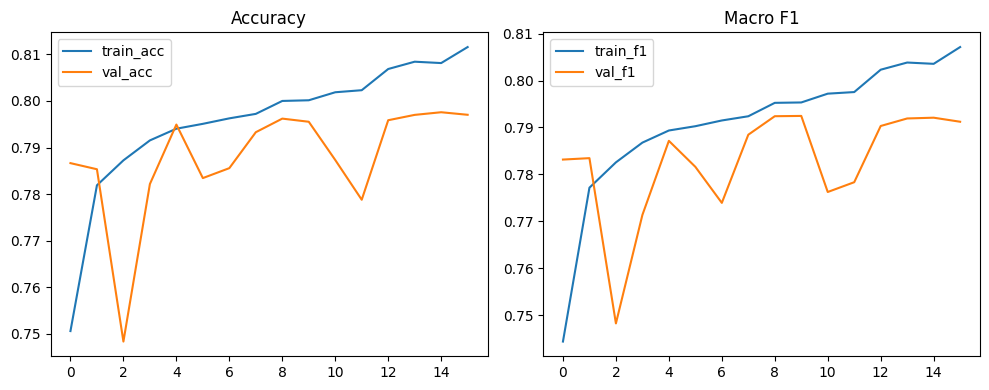

In [24]:
history_df = pd.DataFrame(history)
display(history_df.tail())

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_df['train_acc'], label='train_acc')
plt.plot(history_df['val_acc'], label='val_acc')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history_df['train_f1'], label='train_f1')
plt.plot(history_df['val_f1'], label='val_f1')
plt.legend()
plt.title('Macro F1')
plt.tight_layout()

In [25]:
print(classification_report(te['y_true'], te['y_pred'], target_names=label_names, zero_division=0))

              precision    recall  f1-score   support

        NORM       0.80      0.85      0.82     29856
         ABN       0.81      0.74      0.77     25149

    accuracy                           0.80     55005
   macro avg       0.80      0.80      0.80     55005
weighted avg       0.80      0.80      0.80     55005



In [26]:
summary = {
    'task_mode': TASK_MODE,
    'use_class_balancing': bool(USE_CLASS_BALANCING),
    'best_epoch': int(best_epoch),
    'best_val_f1': float(best_val_f1),
    'test_acc': float(te['acc']),
    'test_f1': float(te['f1']),
    'train_acc_best_epoch': float(history_df.loc[history_df['epoch'] == best_epoch, 'train_acc'].iloc[0]),
    'val_acc_best_epoch': float(history_df.loc[history_df['epoch'] == best_epoch, 'val_acc'].iloc[0]),
    'notes': 'PTB-XL MIT-style beat segmentation: single-lead, fixed length 187, per-beat min-max normalization',
}

with open(RESULTS_DIR / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
history_df.to_json(RESULTS_DIR / 'history.json', orient='records', indent=2)
torch.save({'state_dict': model.state_dict(), 'label_names': label_names, 'task_mode': TASK_MODE}, RESULTS_DIR / 'best_model.pt')

print('Saved artifacts to', RESULTS_DIR)
print(summary)

Saved artifacts to /Users/ayoub/work/MS-DS_ML_Projects/IOT/collective-intelligence/results/phase1_ptbxl_mit_style_notebook
{'task_mode': 'binary', 'use_class_balancing': False, 'best_epoch': 10, 'best_val_f1': 0.792449195671818, 'test_acc': 0.8018543768748295, 'test_f1': 0.7988065746341609, 'train_acc_best_epoch': 0.8001395744149961, 'val_acc_best_epoch': 0.7955295447501322, 'notes': 'PTB-XL MIT-style beat segmentation: single-lead, fixed length 187, per-beat min-max normalization'}


## Why this should behave better than raw-record PTB-XL

This setup aligns PTB-XL with MIT-BIH-style learning:
- beat-level segmentation instead of full 10-second records
- single-lead morphology focus
- fixed-length vectors (187)
- local per-beat normalization

These choices reduce temporal complexity and often make CNN optimization easier.